# 01 Working Research

End-to-end research notebook using existing `src` modules.

## 1) Setup

In [88]:
import warnings
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

# Ensure project root is on sys.path so `import src.*` works.
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.config import load_config

config = load_config()
DATA_DIR = config.data_dir
DATA_DIR.mkdir(parents=True, exist_ok=True)

print('Project root:', project_root)
print('DATA_DIR:', DATA_DIR)


Project root: /Users/ulianahusak/WUTIS_2026/intraday_momentum_ml
DATA_DIR: data


## 2) Fetch data (Alpaca)

### Why Fetch 5 Years of Data

We use a ~5-year fetch window (2021-01-01 to 2026-01-01) to make the research more robust:
- It includes multiple market regimes (trend, drawdown, recovery, range), which reduces overfitting to one period.
- It provides enough candidate trades for walk-forward training/validation/testing splits.
- It stabilizes probability calibration (`p_good`) and threshold/size mapping (e.g., q20/q80).

Tradeoff: data pull and preprocessing are slower, but model and backtest conclusions are more reliable.


In [89]:
from src.data_alpaca import fetch_minute_bars

symbol = "SPY"
start = "2021-01-01"
end = "2026-01-01"   # ~5 years
bars_raw = fetch_minute_bars(symbol=symbol, start=start, end=end, adjustment="raw", force=True)


raw_path = DATA_DIR / 'bars_raw.parquet'
bars_raw.to_parquet(raw_path, index=False)

print('Saved:', raw_path)
print('Rows:', len(bars_raw))
print('Min timestamp:', bars_raw['timestamp'].min() if len(bars_raw) else None)
print('Max timestamp:', bars_raw['timestamp'].max() if len(bars_raw) else None)

bars_raw.head()


Saved: data/bars_raw.parquet
Rows: 1025947
Min timestamp: 2021-01-04 04:00:00-05:00
Max timestamp: 2025-12-31 19:59:00-05:00


,timestamp,open,high,low,close,volume
0,2021-01-04 04:00:00-05:00,375.640000,375.690000,375.640000,375.690000,"2,606.000000"
1,2021-01-04 04:01:00-05:00,375.690000,375.810000,375.690000,375.790000,"16,041.000000"
2,2021-01-04 04:02:00-05:00,375.840000,375.880000,375.790000,375.820000,"12,514.000000"
3,2021-01-04 04:04:00-05:00,375.900000,376.040000,375.900000,375.910000,"8,995.000000"
4,2021-01-04 04:05:00-05:00,375.900000,375.900000,375.880000,375.880000,"4,550.000000"


In [38]:
bars_raw.tail()

,timestamp,open,high,low,close,volume
1025942,2025-12-31 19:54:00-05:00,682.510000,682.519800,682.510000,682.519800,571.000000
1025943,2025-12-31 19:55:00-05:00,682.520000,682.520000,682.500000,682.510000,"1,965.000000"
1025944,2025-12-31 19:56:00-05:00,682.520000,682.520000,682.519700,682.519700,683.000000
1025945,2025-12-31 19:58:00-05:00,682.550000,682.590000,682.550000,682.550000,"1,543.000000"
1025946,2025-12-31 19:59:00-05:00,682.520000,682.590000,682.500000,682.500000,523.000000


## 3) Preprocess

Saved: data/bars_preprocessed.parquet rows= 490705


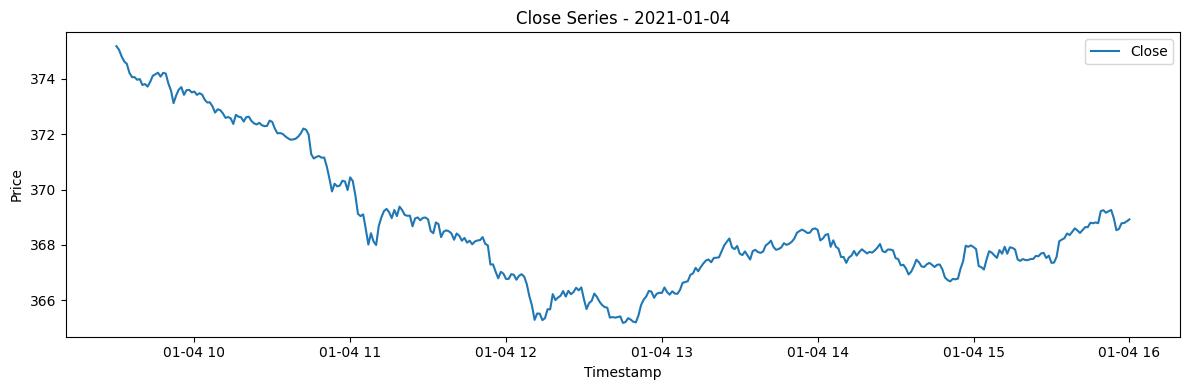

In [90]:
from src.preprocess import preprocess_bars

bars_pre = preprocess_bars(bars_raw)
pre_path = DATA_DIR / 'bars_preprocessed.parquet'
bars_pre.to_parquet(pre_path, index=False)
print('Saved:', pre_path, 'rows=', len(bars_pre))

# Pick first complete day (09:30..16:00 inclusive => 391 rows)
day_counts = bars_pre.groupby('date').size()
complete_days = day_counts[day_counts >= 391].index
sample_day = complete_days[0] if len(complete_days) else bars_pre['date'].iloc[0]

day_df = bars_pre[bars_pre['date'] == sample_day].copy()

plt.figure(figsize=(12, 4))
plt.plot(day_df['timestamp'], day_df['close'], label='Close')
plt.title(f'Close Series - {sample_day}')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


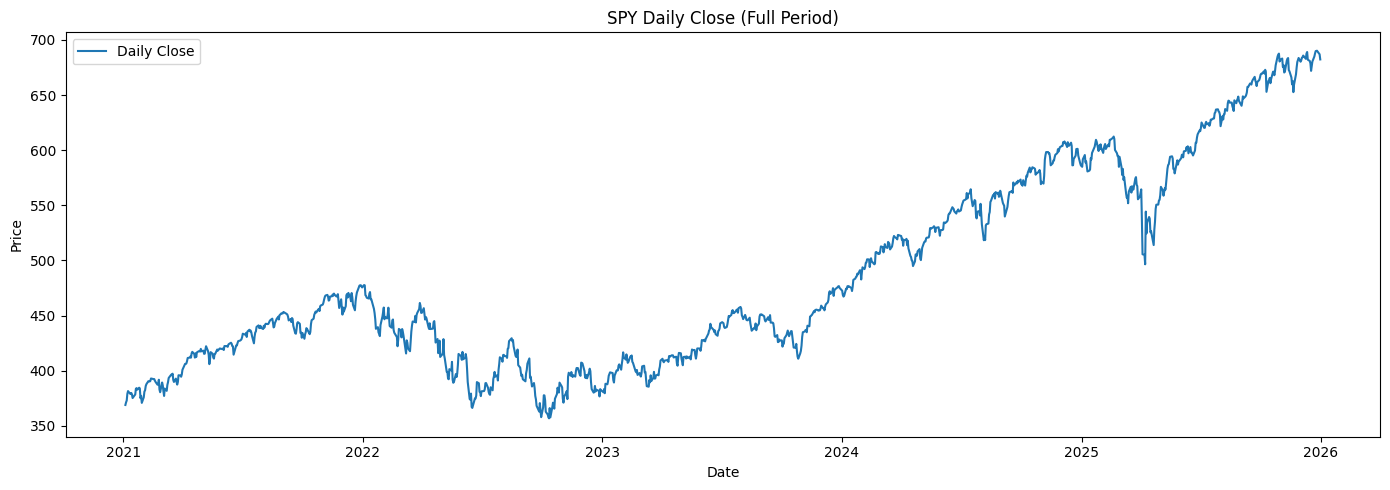

In [91]:
# 1) Full-history daily close (last bar of each day)
daily_close = (
    bars_pre.sort_values("timestamp")
    .groupby("date", as_index=False)["close"]
    .last()
)
daily_close["date"] = pd.to_datetime(daily_close["date"])

plt.figure(figsize=(14, 5))
plt.plot(daily_close["date"], daily_close["close"], label="Daily Close")
plt.title("SPY Daily Close (Full Period)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()


## 4) Indicators (Noise Area + Bands + VWAP)

Saved: data/bars_enriched.parquet rows= 490705


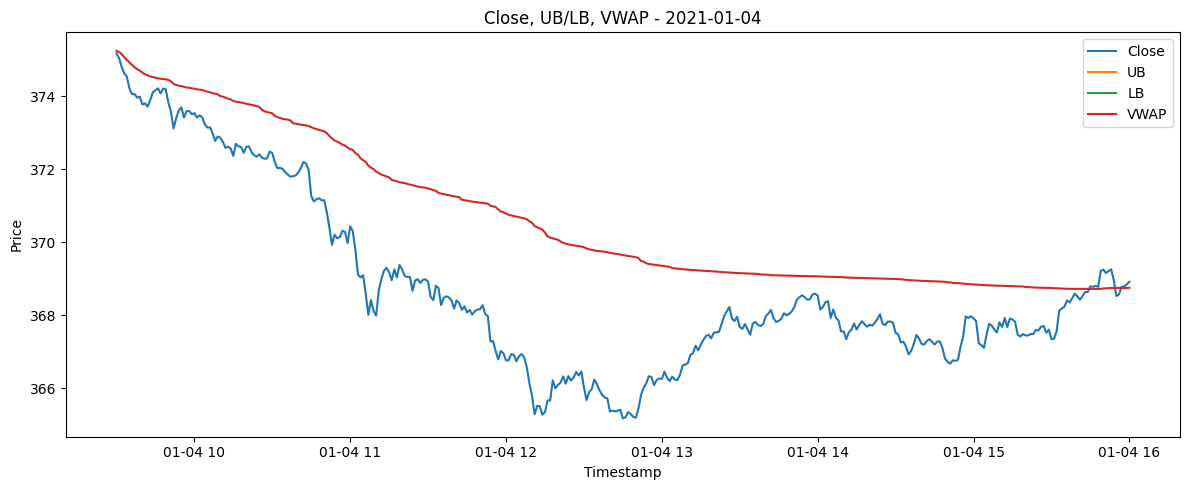

In [92]:
from src.indicators import (
    compute_intraday_move_from_open,
    compute_sigma_profile,
    compute_gap_adjusted_bands,
    compute_vwap,
)

bars_ind = compute_intraday_move_from_open(bars_pre)
bars_ind = compute_sigma_profile(bars_ind, lookback_days=14)
bars_ind = compute_gap_adjusted_bands(bars_ind, vm=1.0)
bars_ind = compute_vwap(bars_ind)

enriched_path = DATA_DIR / 'bars_enriched.parquet'
bars_ind.to_parquet(enriched_path, index=False)
print('Saved:', enriched_path, 'rows=', len(bars_ind))

sample = bars_ind[bars_ind['date'] == sample_day].copy()

plt.figure(figsize=(12, 5))
plt.plot(sample['timestamp'], sample['close'], label='Close')
plt.plot(sample['timestamp'], sample['UB'], label='UB')
plt.plot(sample['timestamp'], sample['LB'], label='LB')
plt.plot(sample['timestamp'], sample['VWAP'], label='VWAP')
plt.title(f'Close, UB/LB, VWAP - {sample_day}')
plt.xlabel('Timestamp')
plt.ylabel('Price')
plt.legend()
plt.tight_layout()
plt.show()


## 5) Baseline backtest (paper strategy)

In [93]:
from src.baseline_strategy import run_baseline_backtest

baseline_out = run_baseline_backtest(bars_ind)
baseline_equity = baseline_out['equity_curve'].copy()
baseline_trades = baseline_out['trades'].copy()
baseline_summary = baseline_out['summary']

# Save outputs like CLI
baseline_equity.to_parquet(DATA_DIR / 'baseline_equity_curve.parquet', index=False)
baseline_trades.to_parquet(DATA_DIR / 'baseline_trades.parquet', index=False)
with open(DATA_DIR / 'baseline_summary.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_summary, f, indent=2, default=str)

pd.DataFrame([baseline_summary]).T.rename(columns={0: 'value'})


,value
sharpe,1.125263
cagr_ish,0.171437
max_drawdown,-0.131538
n_days,"1,255.000000"
final_equity,"219,903.083900"
trades_count,"1,205.000000"
turnover,"6,350.015326"
total_costs,"9,636.282000"


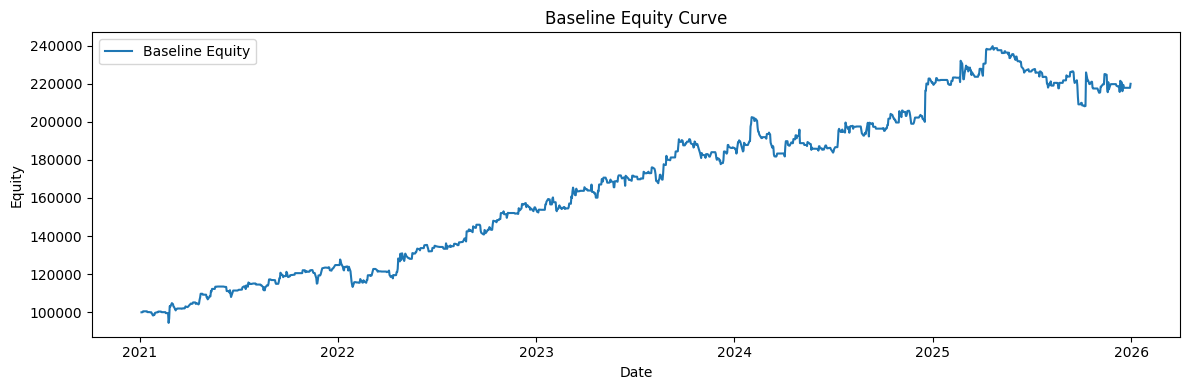

In [94]:
plt.figure(figsize=(12, 4))
plt.plot(pd.to_datetime(baseline_equity['date']), baseline_equity['equity'], label='Baseline Equity')
plt.title('Baseline Equity Curve')
plt.xlabel('Date')
plt.ylabel('Equity')
plt.legend()
plt.tight_layout()
plt.show()


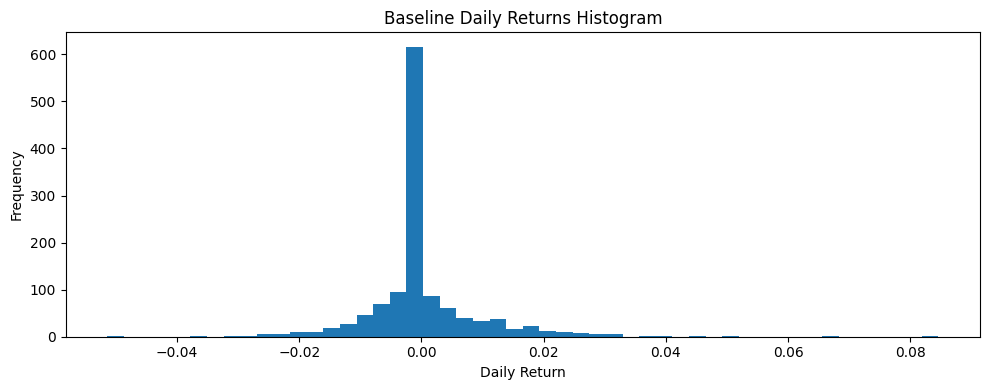

In [95]:
plt.figure(figsize=(10, 4))
plt.hist(baseline_equity['daily_return'].dropna(), bins=50)
plt.title('Baseline Daily Returns Histogram')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


In [96]:
best_days = baseline_equity.nlargest(20, 'daily_return')[['date', 'daily_return', 'daily_pnl']]
worst_days = baseline_equity.nsmallest(20, 'daily_return')[['date', 'daily_return', 'daily_pnl']]

print('Top 20 best days:')
display(best_days)
print('Top 20 worst days:')
display(worst_days)


Top 20 best days:


,date,daily_return,daily_pnl
1198,2025-10-10,0.084609,"17,619.819000"
996,2024-12-18,0.082062,"16,406.875600"
36,2021-02-25,0.066322,"6,417.716000"
1038,2025-02-21,0.050615,"11,176.531000"
328,2022-04-22,0.044112,"5,419.361000"
773,2024-01-31,0.040260,"7,642.313000"
415,2022-08-26,0.038739,"5,313.651000"
924,2024-09-06,0.037547,"7,219.259000"
227,2021-11-26,0.036074,"4,155.312000"
757,2024-01-08,0.032732,"5,999.796000"


Top 20 worst days:


,date,daily_return,daily_pnl
34,2021-02-23,-0.051439,"-5,121.292000"
836,2024-05-01,-0.036226,"-7,095.088000"
1225,2025-11-18,-0.031204,"-7,009.808000"
1187,2025-09-25,-0.027308,"-5,980.981600"
331,2022-04-27,-0.026013,"-3,401.514900"
923,2024-09-05,-0.025834,"-5,098.912000"
527,2023-02-07,-0.025698,"-4,053.888000"
334,2022-05-02,-0.025439,"-3,332.405000"
267,2022-01-25,-0.025088,"-3,050.112000"
225,2021-11-23,-0.024706,"-2,914.193800"


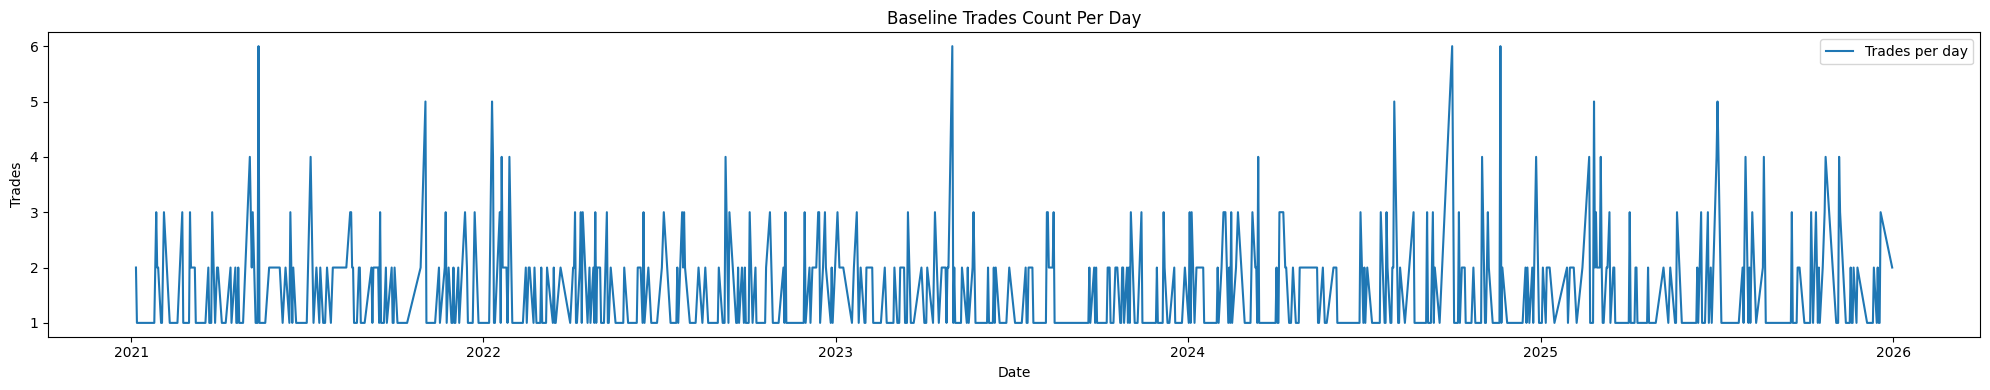

In [97]:
if not baseline_trades.empty:
    trades_per_day = pd.to_datetime(baseline_trades['entry_timestamp']).dt.strftime('%Y-%m-%d').value_counts().sort_index()
else:
    trades_per_day = pd.Series(dtype=int)

plt.figure(figsize=(20, 4))
plt.plot(pd.to_datetime(trades_per_day.index), trades_per_day.values, label='Trades per day')
plt.title('Baseline Trades Count Per Day')
plt.xlabel('Date')
plt.ylabel('Trades')
plt.legend()
plt.tight_layout()
plt.show()


## 6) Build ML dataset (meta-labeling)

In [98]:
from src.features_ml import build_ml_dataset

# Option A (default): baseline_trade label uses realized baseline trade outcome.
# Option B (less noisy target): fixed_horizon label uses next horizon net return.
X, y, meta = build_ml_dataset(
    bars_ind,
    label_mode="fixed_horizon",   # try "baseline_trade" too
    horizon_mins=30,
)

# build_ml_dataset already saves DATA_DIR/ml_dataset.parquet
with open(DATA_DIR / 'ml_dataset_meta.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            'rows': int(len(X)),
            'features': list(X.columns),
            'positive_rate': float(y.mean()) if len(y) else 0.0,
        },
        f,
        indent=2,
    )

print('Rows:', len(X))
print('Class balance (mean y):', float(y.mean()) if len(y) else np.nan)
X.head()


Rows: 1205
Class balance (mean y): 0.5427385892116182


,signed_break_distance,band_width,vwap_diff,intraday_return,ret_30m,realized_vol_30m,whipsaw_60m,time_of_day_minutes,tod_sin,tod_cos
0,0.001798,0.015776,0.005981,0.011839,0.005124,0.000378,3.000000,60,0.822984,0.568065
1,0.000010,0.030813,0.005465,0.017568,-0.001128,0.000274,0.000000,240,-0.663123,-0.748511
2,0.000062,0.023978,0.003744,0.007843,0.003176,0.000379,0.000000,60,0.822984,0.568065
3,0.001175,0.014248,-0.001934,-0.005933,-0.006724,0.000746,0.000000,60,0.822984,0.568065
4,0.000089,0.020477,0.003419,0.006848,0.000887,0.000113,0.000000,210,-0.239316,-0.970942


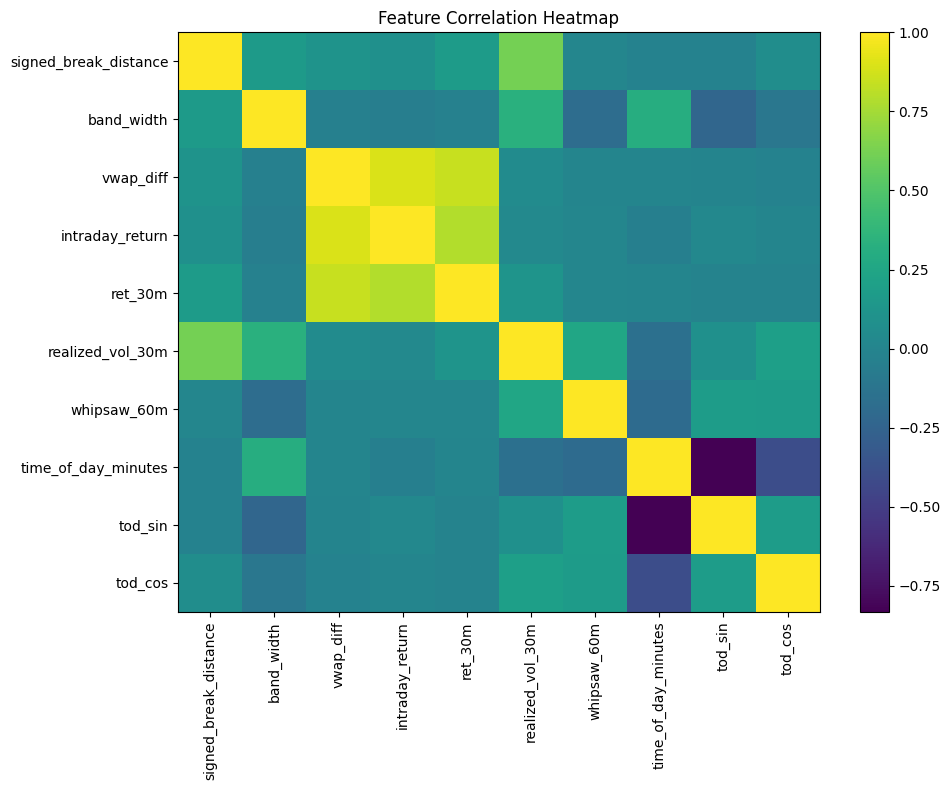

In [99]:
corr = X.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
im = plt.imshow(corr.values, aspect='auto')
plt.colorbar(im)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()


## 7) Train ML (walk-forward)

### 7.1 Train And Load Report

Why this matters: this gives the selected model, chosen threshold/quantiles, and per-split results before any backtest overlay is run.

In [100]:
from src.train_ml import train_walk_forward_models

# Rolling walk-forward setup: past -> validate -> future test, then roll.
train_out = train_walk_forward_models(
    train_months=24,
    val_months=3,
    test_months=3,
    step_months=3,
)
report_path = Path(train_out['report_path'])

with open(report_path, 'r', encoding='utf-8') as f:
    report = json.load(f)

best = report.get('best', {})
print('Best model:', best.get('model_name'))
print('Selected threshold:', best.get('threshold'))
print('q20/q40/q60/q80:', best.get('prob_q20'), best.get('prob_q40'), best.get('prob_q60'), best.get('prob_q80'))
print('Report file:', report_path)


[LightGBM] [Info] Number of positive: 269, number of negative: 209
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000344 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1003
[LightGBM] [Info] Number of data points in the train set: 478, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


### 7.2 Split-Level Classification Metrics

Why this matters: AUC/precision/recall tell whether ranking and directional classification are stable across time splits, not just on one window.

In [101]:
split_rows = []
for split in report.get('splits', []):
    sid = split.get('split_id')
    for model_name, vals in split.get('models', {}).items():
        split_rows.append(
            {
                'split_id': sid,
                'model': model_name,
                'val_auc': vals.get('validation', {}).get('auc'),
                'test_auc': vals.get('test', {}).get('auc'),
                'val_precision': vals.get('validation', {}).get('precision'),
                'val_recall': vals.get('validation', {}).get('recall'),
                'test_precision': vals.get('test', {}).get('precision'),
                'test_recall': vals.get('test', {}).get('recall'),
                'threshold': vals.get('threshold'),
            }
        )

auc_df = pd.DataFrame(split_rows)
display(auc_df.head(20))

if not auc_df.empty:
    summary_cls = (
        auc_df.groupby('model', as_index=False)
        .agg(
            splits=('split_id', 'nunique'),
            val_auc_mean=('val_auc', 'mean'),
            test_auc_mean=('test_auc', 'mean'),
            test_auc_std=('test_auc', 'std'),
            test_precision_mean=('test_precision', 'mean'),
            test_recall_mean=('test_recall', 'mean'),
        )
    )
    display(summary_cls)


,split_id,model,val_auc,test_auc,val_precision,val_recall,test_precision,test_recall,threshold
0,0,logistic,0.514946,0.554080,0.800000,0.125000,0.714286,0.161290,0.600000
1,0,lightgbm,0.540761,0.578748,0.581818,1.000000,0.476923,1.000000,0.500000
2,1,logistic,0.529412,0.405797,1.000000,0.096774,0.000000,0.000000,0.520000
3,1,lightgbm,0.674099,0.431159,0.000000,0.000000,0.000000,0.000000,0.500000
4,2,logistic,0.575362,0.463728,0.857143,0.200000,0.400000,0.060606,0.620000
5,2,lightgbm,0.505797,0.532140,0.566038,1.000000,0.500000,1.000000,0.500000
6,3,logistic,0.530762,0.502604,0.484848,0.484848,0.434783,0.312500,0.500000
7,3,lightgbm,0.480716,0.372396,0.413793,0.363636,0.333333,0.437500,0.500000
8,4,logistic,0.562500,0.582645,0.000000,0.000000,0.000000,0.000000,0.500000
9,4,lightgbm,0.616753,0.311295,0.000000,0.000000,0.000000,0.000000,0.500000


,model,splits,val_auc_mean,test_auc_mean,test_auc_std,test_precision_mean,test_recall_mean
0,lightgbm,11,0.565155,0.481323,0.104061,0.422269,0.532610
1,logistic,11,0.577235,0.540526,0.081391,0.524141,0.160368


### 7.3 Split-Level Trading Metrics

Why this matters: good classification scores are not enough; we need economic usefulness (Sharpe/mean return/take-rate) on forward test windows.

In [102]:
trade_rows = []
for split in report.get('splits', []):
    sid = split.get('split_id')
    for model_name, vals in split.get('models', {}).items():
        test_m = vals.get('test', {})
        val_m = vals.get('validation', {})
        trade_rows.append(
            {
                'split_id': sid,
                'model': model_name,
                'val_net_sharpe': val_m.get('net_sharpe'),
                'test_net_sharpe': test_m.get('net_sharpe'),
                'val_net_mean_return': val_m.get('net_mean_return'),
                'test_net_mean_return': test_m.get('net_mean_return'),
                'test_take_rate': test_m.get('take_rate'),
                'test_n_trades': test_m.get('n_trades'),
            }
        )

trade_df = pd.DataFrame(trade_rows)
display(trade_df.head(20))

if not trade_df.empty:
    summary_trade = (
        trade_df.groupby('model', as_index=False)
        .agg(
            test_net_sharpe_mean=('test_net_sharpe', 'mean'),
            test_net_sharpe_std=('test_net_sharpe', 'std'),
            test_net_mean_return_mean=('test_net_mean_return', 'mean'),
            test_take_rate_mean=('test_take_rate', 'mean'),
            test_n_trades_mean=('test_n_trades', 'mean'),
        )
    )
    display(summary_trade)


,split_id,model,val_net_sharpe,test_net_sharpe,val_net_mean_return,test_net_mean_return,test_take_rate,test_n_trades
0,0,logistic,5.356995,5.385487,0.001294,0.000800,0.107692,7.000000
1,0,lightgbm,0.165160,-0.980955,0.000031,-0.000123,1.000000,65.000000
2,1,logistic,32.657743,-16.421326,0.002363,-0.001408,0.056604,3.000000
3,1,lightgbm,-999.000000,-999.000000,0.000000,0.000000,0.000000,0.000000
4,2,logistic,13.075114,10.551968,0.000953,0.000713,0.075758,5.000000
5,2,lightgbm,3.059757,-0.040690,0.000356,-0.000005,1.000000,66.000000
6,3,logistic,0.519677,-5.421160,0.000064,-0.000532,0.338235,23.000000
7,3,lightgbm,-1.744715,-5.305016,-0.000203,-0.000527,0.617647,42.000000
8,4,logistic,-999.000000,-999.000000,0.000000,0.000000,0.000000,0.000000
9,4,lightgbm,-999.000000,-999.000000,0.000000,0.000000,0.000000,0.000000


,model,test_net_sharpe_mean,test_net_sharpe_std,test_net_mean_return_mean,test_take_rate_mean,test_n_trades_mean
0,lightgbm,-182.787285,403.555338,-0.000195,0.549939,35.545455
1,logistic,-91.036879,301.232843,0.000813,0.153385,9.545455


### 7.4 Calibration Check

Why this matters: soft sizing depends on probability quality. Calibration checks whether predicted probabilities align with observed outcomes.

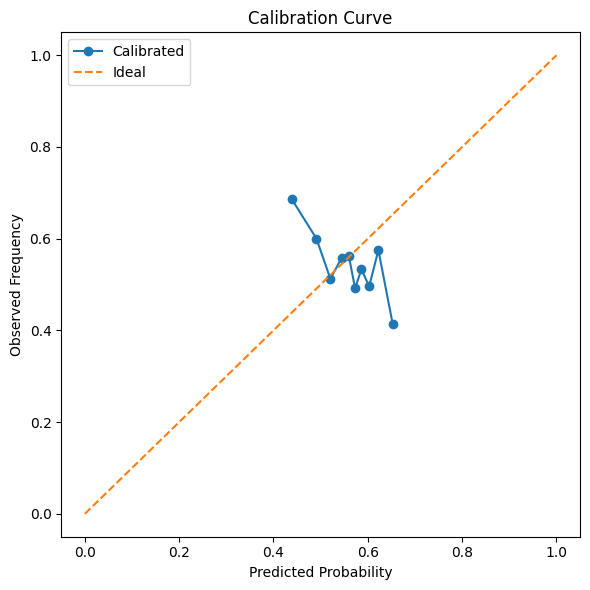

In [103]:
from sklearn.calibration import calibration_curve
import joblib

try:
    model = joblib.load(train_out['best_model_path'])
    calibrator = joblib.load(train_out['calibration_path'])
    ds = pd.read_parquet(DATA_DIR / 'ml_dataset.parquet')

    feature_cols = report.get('feature_columns', [c for c in ds.columns if c not in {'date','timestamp','side','y','pnl','trade_return','costs'}])
    X_all = ds[feature_cols]
    y_all = ds['y'].astype(int)

    if hasattr(model, 'decision_function'):
        raw_scores = np.asarray(model.decision_function(X_all), dtype=float)
    else:
        p_raw = np.asarray(model.predict_proba(X_all)[:, 1], dtype=float)
        p_raw = np.clip(p_raw, 1e-8, 1 - 1e-8)
        raw_scores = np.log(p_raw / (1 - p_raw))

    p_cal = calibrator.predict_proba(raw_scores)
    frac_pos, mean_pred = calibration_curve(y_all, p_cal, n_bins=10, strategy='quantile')

    plt.figure(figsize=(6, 6))
    plt.plot(mean_pred, frac_pos, marker='o', label='Calibrated')
    plt.plot([0, 1], [0, 1], linestyle='--', label='Ideal')
    plt.title('Calibration Curve')
    plt.xlabel('Predicted Probability')
    plt.ylabel('Observed Frequency')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Calibration curve unavailable:', exc)


### 7.5 Ranking Power (Decile Test)

Why this matters: for sizing overlays, we care that higher `p_good` buckets have better realized return profile than lower buckets.

,decile,n,mean_trade_return,win_rate,p_good_mean
0,0,121,0.000593,0.685950,0.438892
1,1,120,0.000161,0.600000,0.491175
2,2,121,-0.000039,0.512397,0.520625
3,3,120,0.000280,0.558333,0.544648
4,4,121,0.000200,0.561983,0.559820
5,5,120,0.000110,0.491667,0.573093
6,6,120,0.000206,0.533333,0.586570
7,7,121,0.000025,0.495868,0.602837
8,8,120,0.000259,0.575000,0.622483
9,9,121,-0.000652,0.413223,0.652923


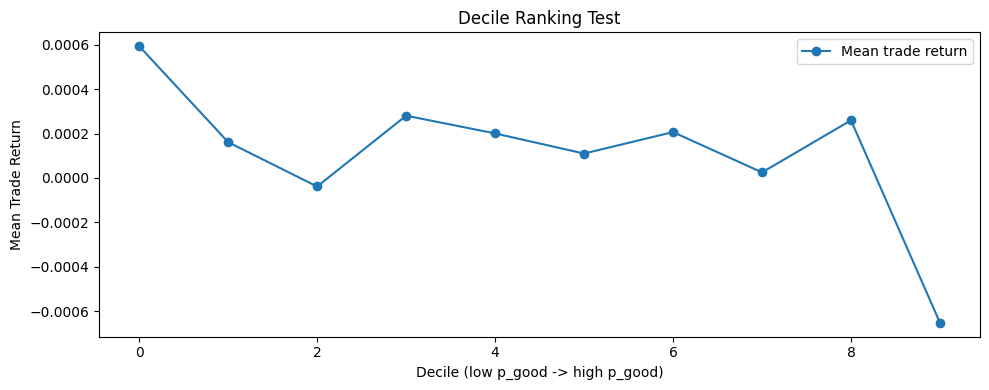

In [104]:
try:
    ds = pd.read_parquet(DATA_DIR / 'ml_dataset.parquet').copy()
    if 'trade_return' not in ds.columns:
        ds['trade_return'] = ds['y'].map({1: 1.0, 0: -1.0})

    feature_cols = report.get('feature_columns', [c for c in ds.columns if c not in {'date','timestamp','side','y','pnl','trade_return','costs'}])
    X_all = ds[feature_cols]

    if 'model' not in locals() or 'calibrator' not in locals():
        model = joblib.load(train_out['best_model_path'])
        calibrator = joblib.load(train_out['calibration_path'])

    if hasattr(model, 'decision_function'):
        raw_scores = np.asarray(model.decision_function(X_all), dtype=float)
    else:
        p_raw = np.asarray(model.predict_proba(X_all)[:, 1], dtype=float)
        p_raw = np.clip(p_raw, 1e-8, 1 - 1e-8)
        raw_scores = np.log(p_raw / (1 - p_raw))

    ds['p_good'] = calibrator.predict_proba(raw_scores)
    ds['decile'] = pd.qcut(ds['p_good'], 10, labels=False, duplicates='drop')

    decile_stats = (
        ds.groupby('decile', as_index=False)
        .agg(
            n=('trade_return', 'size'),
            mean_trade_return=('trade_return', 'mean'),
            win_rate=('y', 'mean'),
            p_good_mean=('p_good', 'mean'),
        )
    )
    display(decile_stats)

    plt.figure(figsize=(10, 4))
    plt.plot(decile_stats['decile'], decile_stats['mean_trade_return'], marker='o', label='Mean trade return')
    plt.title('Decile Ranking Test')
    plt.xlabel('Decile (low p_good -> high p_good)')
    plt.ylabel('Mean Trade Return')
    plt.legend()
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print('Decile test unavailable:', exc)


## 8) ML-filtered backtest

This section compares two ML integration styles on top of the same baseline strategy:

1. **Hard filter (diagnostic)**
- Use `p_good >= threshold` to accept/reject candidate entries.
- This is useful for understanding score selectivity and whether strict gating helps.

2. **Soft sizing (production path)**
- Keep baseline direction logic, but scale shares by model confidence.
- We map `p_good` into a size multiplier using `q20/q80` anchors and clip into `[size_floor, size_cap]` (default `0.5x..1.5x`).

- This preserves trade coverage and typically avoids the missed-trend problem of hard skips.

The code below first sweeps hard-filter thresholds (for diagnostics), then runs soft sizing and compares:
- baseline
- best hard-filter variant
- soft-size variant

The selected ML variant (for plots and exported outputs) is whichever has better Sharpe, then final equity.


### Section 8 Overlay Controls

Production ML integration uses **soft sizing only**, with two stabilizers:
- **Conditional overlay:** overlay is enabled only when recent lookback decile spread is positive (`top_decile_pnl - bottom_decile_pnl > 0`).
- **Neutral zone:** no resizing in the noisy middle (`q40..q60`), so `size_mult=1.0` there.

This reduces regime-specific over-tilting and avoids micro-adjustments in low-confidence regions.

### 8.1 Prepare Candidate Probabilities

Load model-driven candidate probabilities (`p_good`) from baseline candidate events.

In [105]:
import json
from src.backtest_ml_filter import run_ml_filtered_backtest

probe_out = run_ml_filtered_backtest(
    bars_ind,
    flip_reject_mode="hold",
    filter_mode="entry_only",
    allocation_mode="hard_filter",
)
decisions = probe_out["candidate_decisions"].dropna(subset=["p_good"]).copy()
if decisions.empty:
    raise RuntimeError("No candidate decisions with p_good available for threshold tuning.")

display(decisions[["timestamp", "p_good"]].head())
print("candidate rows:", len(decisions))


,timestamp,p_good
0,2021-01-06 10:30:00-05:00,0.439600
1,2021-01-06 11:00:00-05:00,0.529920
2,2021-01-06 11:30:00-05:00,0.547516
3,2021-01-06 13:30:00-05:00,0.554467
4,2021-01-06 14:00:00-05:00,0.494399


candidate rows: 3348


### 8.2 Hard Filter Sweep (Diagnostic Only)

This is a reference test to show how strict trade skipping behaves across thresholds.

In [106]:
cfg = load_config()
models_dir = cfg.data_dir / "models"
models_dir.mkdir(parents=True, exist_ok=True)

quantiles = [0.50, 0.55, 0.60, 0.65, 0.70]
hard_results, hard_runs = [], {}

for q in quantiles:
    thr = float(decisions["p_good"].quantile(q))
    thr_file = models_dir / f"selected_threshold_q{int(q*100)}.json"
    thr_file.write_text(json.dumps({"threshold": thr}, indent=2), encoding="utf-8")

    out_q = run_ml_filtered_backtest(
        bars_ind,
        threshold_path=thr_file,
        flip_reject_mode="hold",
        filter_mode="entry_only",
        allocation_mode="hard_filter",
    )
    m = out_q["metrics"]
    hard_results.append(
        {
            "mode": "hard_filter",
            "quantile": q,
            "threshold": thr,
            "accept_rate": float(out_q["candidate_decisions"]["accepted"].mean()) if len(out_q["candidate_decisions"]) else 0.0,
            "final_equity": float(m.get("final_equity", float("nan"))),
            "sharpe": float(m.get("sharpe", float("nan"))),
            "max_drawdown": float(m.get("max_drawdown", float("nan"))),
            "trades_count": int(m.get("trades_count", 0)),
        }
    )
    hard_runs[q] = out_q

hard_df = pd.DataFrame(hard_results).sort_values(["sharpe", "final_equity"], ascending=False).reset_index(drop=True)
hard_best = hard_df.iloc[0]
best_q = float(hard_best["quantile"])
best_thr = float(hard_best["threshold"])
hard_best_out = hard_runs[best_q]

display(hard_df)
print(f"Selected hard-filter quantile: {best_q:.2f}")
print(f"Selected hard-filter threshold: {best_thr:.6f}")


,mode,quantile,threshold,accept_rate,final_equity,sharpe,max_drawdown,trades_count
0,hard_filter,0.500000,0.561759,0.489431,"151,300.029800",0.705475,-0.116075,903
1,hard_filter,0.550000,0.568077,0.436280,"147,997.560700",0.679143,-0.114277,849
2,hard_filter,0.600000,0.573804,0.391918,"135,478.934000",0.545687,-0.119102,805
3,hard_filter,0.650000,0.579745,0.335294,"128,230.725500",0.461090,-0.130405,741
4,hard_filter,0.700000,0.587095,0.281720,"124,646.968600",0.424598,-0.108866,675


Selected hard-filter quantile: 0.50
Selected hard-filter threshold: 0.561759


### 8.3 Persist Probability Anchors for Soft Sizing

Save threshold and quantile anchors (`q20/q40/q60/q80`) used by the production sizing map.

In [107]:
q20 = float(decisions["p_good"].quantile(0.20))
q40 = float(decisions["p_good"].quantile(0.40))
q60 = float(decisions["p_good"].quantile(0.60))
q80 = float(decisions["p_good"].quantile(0.80))

selected_threshold_path = models_dir / "selected_threshold.json"
selected_threshold_path.write_text(
    json.dumps(
        {
            "threshold": best_thr,
            "source": "notebook_quantile_sweep",
            "quantile": best_q,
            "prob_q20": q20,
            "prob_q40": q40,
            "prob_q60": q60,
            "prob_q80": q80,
        },
        indent=2,
    ),
    encoding="utf-8",
)

print(f"Soft-size q20/q40/q60/q80: {q20:.6f}, {q40:.6f}, {q60:.6f}, {q80:.6f}")
print("Saved:", selected_threshold_path)


Soft-size q20/q40/q60/q80: 0.512676, 0.550016, 0.573804, 0.601251
Saved: data/models/selected_threshold.json


### 8.4 Run Production Soft Sizing

Run the production overlay (conditional + neutral-zone soft sizing), then compare against baseline and diagnostic hard-filter.

In [108]:
soft_out = run_ml_filtered_backtest(
    bars_ind,
    threshold_path=selected_threshold_path,
    flip_reject_mode="hold",
    filter_mode="entry_only",
    allocation_mode="soft_size",
    size_floor=0.85,
    size_cap=1.15,
    neutral_zone=True,
    regime_overlay=True,
    regime_lookback_months=6,
    regime_min_trades=80,
)

soft_metrics = soft_out["metrics"]
hard_metrics = hard_best_out["metrics"]
base_metrics = hard_best_out["baseline_summary"]

mode_compare = pd.DataFrame(
    [
        {
            "mode": "baseline",
            "final_equity": float(base_metrics.get("final_equity", float("nan"))),
            "sharpe": float(base_metrics.get("sharpe", float("nan"))),
            "max_drawdown": float(base_metrics.get("max_drawdown", float("nan"))),
            "trades_count": int(base_metrics.get("trades_count", 0)),
        },
        {
            "mode": "hard_filter_best",
            "final_equity": float(hard_metrics.get("final_equity", float("nan"))),
            "sharpe": float(hard_metrics.get("sharpe", float("nan"))),
            "max_drawdown": float(hard_metrics.get("max_drawdown", float("nan"))),
            "trades_count": int(hard_metrics.get("trades_count", 0)),
        },
        {
            "mode": "soft_size",
            "final_equity": float(soft_metrics.get("final_equity", float("nan"))),
            "sharpe": float(soft_metrics.get("sharpe", float("nan"))),
            "max_drawdown": float(soft_metrics.get("max_drawdown", float("nan"))),
            "trades_count": int(soft_metrics.get("trades_count", 0)),
            "avg_size_mult": float(soft_metrics.get("avg_size_mult", 1.0)),
            "overlay_enabled_rate": float(soft_metrics.get("overlay_enabled_rate", 0.0)),
        },
    ]
)

# production selection
selected_mode = "soft_size"
ml_out = soft_out
ml_equity = ml_out['equity_curve'].copy()
ml_trades = ml_out['trades'].copy()
ml_metrics = ml_out['metrics']
comparison = ml_out['comparison'].copy()

display(mode_compare)
display(comparison)


,mode,final_equity,sharpe,max_drawdown,trades_count,avg_size_mult,overlay_enabled_rate
0,baseline,"219,903.083900",1.125263,-0.131538,1205,NaN,NaN
1,hard_filter_best,"151,300.029800",0.705475,-0.116075,903,NaN,NaN
2,soft_size,"224,812.812000",1.142612,-0.132117,1205,1.006278,0.341909


,baseline,ml_filter,delta
final_equity,"219,903.083900","224,812.812000","4,909.728100"
sharpe,1.125263,1.142612,0.017349
cagr_ish,0.171437,0.176643,0.005205
max_drawdown,-0.131538,-0.132117,-0.000579
trades_count,"1,205.000000","1,205.000000",0.000000
turnover,"6,350.015326","6,413.598918",63.583592
total_costs,"9,636.282000","9,764.838000",128.556000


### 8.5 Save Outputs

Write selected ML outputs back to `DATA_DIR` (same pattern as CLI).

In [109]:
ml_equity.to_parquet(DATA_DIR / 'ml_equity_curve.parquet', index=False)
ml_trades.to_parquet(DATA_DIR / 'ml_trades.parquet', index=False)
comparison.to_parquet(DATA_DIR / 'ml_vs_baseline.parquet', index=True)
if not ml_out['candidate_decisions'].empty:
    ml_out['candidate_decisions'].to_parquet(DATA_DIR / 'ml_candidate_decisions.parquet', index=False)

with open(DATA_DIR / 'ml_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(ml_metrics, f, indent=2, default=str)
with open(DATA_DIR / 'ml_vs_baseline.json', 'w', encoding='utf-8') as f:
    json.dump(
        {
            'baseline_summary': ml_out['baseline_summary'],
            'ml_metrics': ml_metrics,
            'comparison': comparison.to_dict(orient='index'),
            'selected_threshold': best_thr,
            'selected_quantile': best_q,
            'threshold_sweep': hard_results,
            'mode_compare': mode_compare.to_dict(orient='records'),
            'selected_ml_variant': selected_mode,
        },
        f,
        indent=2,
        default=str,
    )

print('Saved ML outputs to DATA_DIR')


Saved ML outputs to DATA_DIR


### 8.6 Performance validation and interpretation

We look at ML results in this order:
1. **Level**: final equity and CAGR-ish (did we make more money?).
2. **Risk-adjusted quality**: Sharpe and max drawdown (did we improve return per unit risk?).
3. **Consistency through time**: monthly return delta vs baseline (is improvement concentrated in one period?).
4. **Execution footprint**: trades count/turnover/costs (did gains come from hidden over-trading?).
5. **Overlay behavior**: size multipliers and outcome by size bucket (is confidence-based sizing actually informative?).

This helps avoid false confidence from a single headline metric.


In [110]:
# Consolidated summary table used for interpretation
summary_rows = [
    {
        'strategy': 'baseline',
        'final_equity': float(base_metrics.get('final_equity', np.nan)),
        'sharpe': float(base_metrics.get('sharpe', np.nan)),
        'cagr_ish': float(base_metrics.get('cagr_ish', np.nan)),
        'max_drawdown': float(base_metrics.get('max_drawdown', np.nan)),
        'trades_count': float(base_metrics.get('trades_count', np.nan)),
        'turnover': float(base_metrics.get('turnover', np.nan)),
        'total_costs': float(base_metrics.get('total_costs', np.nan)),
    },
    {
        'strategy': 'ml_selected',
        'final_equity': float(ml_metrics.get('final_equity', np.nan)),
        'sharpe': float(ml_metrics.get('sharpe', np.nan)),
        'cagr_ish': float(ml_metrics.get('cagr_ish', np.nan)),
        'max_drawdown': float(ml_metrics.get('max_drawdown', np.nan)),
        'trades_count': float(ml_metrics.get('trades_count', np.nan)),
        'turnover': float(ml_metrics.get('turnover', np.nan)),
        'total_costs': float(ml_metrics.get('total_costs', np.nan)),
        'avg_size_mult': float(ml_metrics.get('avg_size_mult', np.nan)),
        'overlay_enabled_rate': float(ml_metrics.get('overlay_enabled_rate', np.nan)),
    },
]
summary_df = pd.DataFrame(summary_rows).set_index('strategy')
summary_df.loc['delta_ml_minus_base'] = summary_df.loc['ml_selected'] - summary_df.loc['baseline']

display(summary_df)

print('Interpretation tips:')
print('- Prefer ML only if final_equity/CAGR improve without a disproportionate Sharpe or drawdown deterioration.')
print('- avg_size_mult near 1.0 means the overlay is mild; far from 1.0 means stronger active sizing.')
print('- If turnover and costs rise too much, check whether net gains still justify complexity.')


,final_equity,sharpe,cagr_ish,max_drawdown,trades_count,turnover,total_costs,avg_size_mult,overlay_enabled_rate
strategy,,,,,,,,,
baseline,"219,903.083900",1.125263,0.171437,-0.131538,"1,205.000000","6,350.015326","9,636.282000",NaN,NaN
ml_selected,"224,812.812000",1.142612,0.176643,-0.132117,"1,205.000000","6,413.598918","9,764.838000",1.006278,0.341909
delta_ml_minus_base,"4,909.728100",0.017349,0.005205,-0.000579,0.000000,63.583592,128.556000,NaN,NaN


Interpretation tips:
- Prefer ML only if final_equity/CAGR improve without a disproportionate Sharpe or drawdown deterioration.
- avg_size_mult near 1.0 means the overlay is mild; far from 1.0 means stronger active sizing.
- If turnover and costs rise too much, check whether net gains still justify complexity.


### 8.7 Risk and path diagnostics

Why these plots:
- **Equity curve** shows absolute wealth evolution.
- **Drawdown curve** shows pain profile and recovery speed.
- **Rolling relative return** highlights time blocks where ML helps/hurts versus baseline.


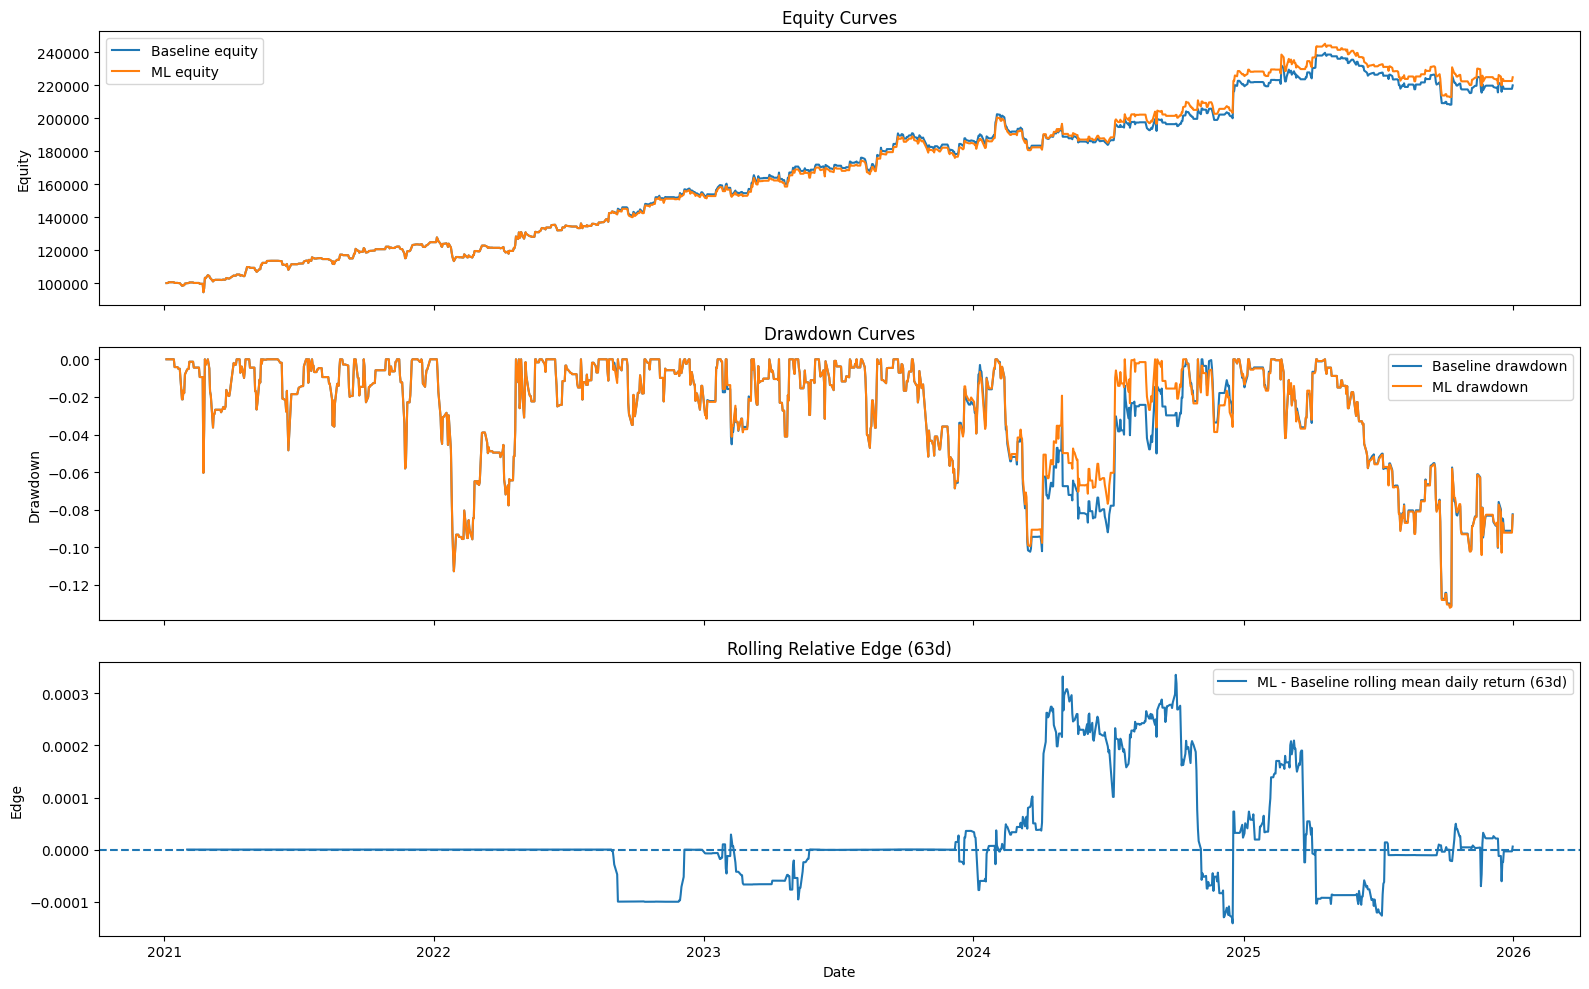

In [112]:
eq_base = baseline_equity.copy()
eq_ml = ml_equity.copy()

for df in (eq_base, eq_ml):
    df['date'] = pd.to_datetime(df['date'])
    df.sort_values('date', inplace=True)

# Drawdown series
def drawdown_series(equity: pd.Series) -> pd.Series:
    running_max = equity.cummax()
    return equity / running_max - 1.0

eq_base['drawdown'] = drawdown_series(eq_base['equity'])
eq_ml['drawdown'] = drawdown_series(eq_ml['equity'])

# Rolling relative edge (63 trading days ~ 3 months)
ret_base = eq_base.set_index('date')['daily_return']
ret_ml = eq_ml.set_index('date')['daily_return']
ret_cmp = pd.concat([ret_base.rename('base'), ret_ml.rename('ml')], axis=1).dropna()
ret_cmp['edge'] = ret_cmp['ml'] - ret_cmp['base']
ret_cmp['edge_63d_mean'] = ret_cmp['edge'].rolling(63, min_periods=20).mean()

fig, axes = plt.subplots(3, 1, figsize=(16, 10), sharex=True)
axes[0].plot(eq_base['date'], eq_base['equity'], label='Baseline equity')
axes[0].plot(eq_ml['date'], eq_ml['equity'], label='ML equity')
axes[0].set_title('Equity Curves')
axes[0].set_ylabel('Equity')
axes[0].legend()

axes[1].plot(eq_base['date'], eq_base['drawdown'], label='Baseline drawdown')
axes[1].plot(eq_ml['date'], eq_ml['drawdown'], label='ML drawdown')
axes[1].set_title('Drawdown Curves')
axes[1].set_ylabel('Drawdown')
axes[1].legend()

axes[2].plot(ret_cmp.index, ret_cmp['edge_63d_mean'], label='ML - Baseline rolling mean daily return (63d)')
axes[2].axhline(0.0, linestyle='--')
axes[2].set_title('Rolling Relative Edge (63d)')
axes[2].set_ylabel('Edge')
axes[2].set_xlabel('Date')
axes[2].legend()

plt.tight_layout()
plt.show()


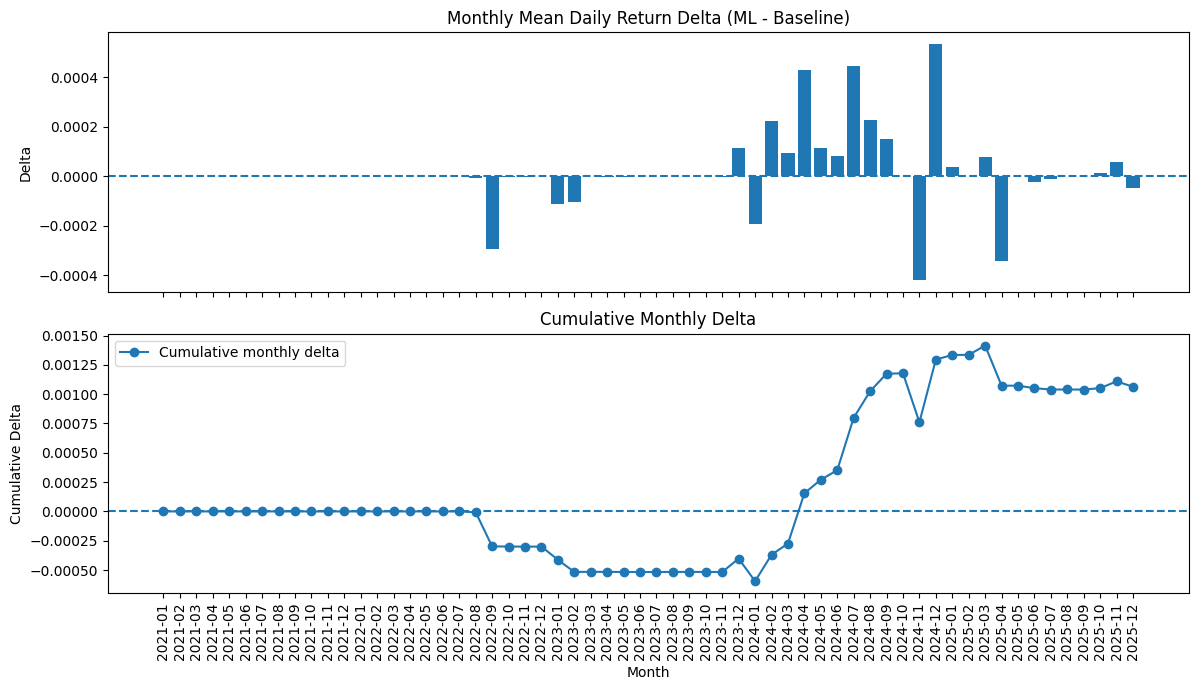

Months with strongest ML underperformance:


,month,daily_return_base,daily_return_ml,delta,cum_delta
46,2024-11,-0.000796,-0.001214,-0.000418,0.000761
51,2025-04,0.002048,0.001705,-0.000343,0.001072
20,2022-09,-0.000599,-0.000890,-0.000291,-0.000299
36,2024-01,0.002808,0.002616,-0.000192,-0.000595
24,2023-01,0.001486,0.001373,-0.000113,-0.000413
25,2023-02,-0.001674,-0.001778,-0.000104,-0.000516


In [113]:
# Monthly consistency: where ML adds or subtracts value
m_base = eq_base.assign(month=eq_base['date'].dt.to_period('M').astype(str)).groupby('month', as_index=False)['daily_return'].mean()
m_ml = eq_ml.assign(month=eq_ml['date'].dt.to_period('M').astype(str)).groupby('month', as_index=False)['daily_return'].mean()
m_cmp = m_base.merge(m_ml, on='month', suffixes=('_base', '_ml'))
m_cmp['delta'] = m_cmp['daily_return_ml'] - m_cmp['daily_return_base']
m_cmp['cum_delta'] = m_cmp['delta'].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].bar(m_cmp['month'], m_cmp['delta'])
axes[0].axhline(0.0, linestyle='--')
axes[0].set_title('Monthly Mean Daily Return Delta (ML - Baseline)')
axes[0].set_ylabel('Delta')

axes[1].plot(m_cmp['month'], m_cmp['cum_delta'], marker='o', label='Cumulative monthly delta')
axes[1].axhline(0.0, linestyle='--')
axes[1].set_title('Cumulative Monthly Delta')
axes[1].set_ylabel('Cumulative Delta')
axes[1].set_xlabel('Month')
axes[1].legend()

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print('Months with strongest ML underperformance:')
display(m_cmp.nsmallest(6, 'delta'))


### 8.8 Overlay behavior diagnostics

These checks answer: **is ML confidence being translated into sensible sizing?**
- If larger `size_mult` buckets have better realized PnL (or at least not worse), ranking is useful.
- If all buckets look random/noisy, sizing map is likely overfitting or too weak.


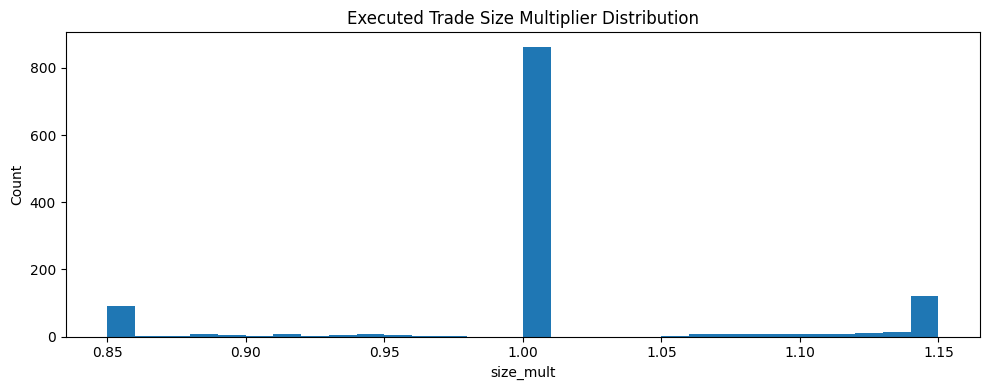

In [116]:
dec = ml_out['candidate_decisions'].copy()
tr = ml_out['trades'].copy()

if dec.empty or tr.empty:
    print('No candidate decisions or trades available for overlay diagnostics.')
else:
    dec['timestamp'] = pd.to_datetime(dec['timestamp'])
    tr['entry_timestamp'] = pd.to_datetime(tr['entry_timestamp'])
    tr['exit_timestamp'] = pd.to_datetime(tr['exit_timestamp'])
    tr['win'] = (tr['pnl'] > 0).astype(int)

    # Attach decision-time ML fields to each executed trade
    join_cols = [c for c in ['timestamp', 'p_good', 'size_mult'] if c in dec.columns]
    eval_df = tr.merge(dec[join_cols], left_on='entry_timestamp', right_on='timestamp', how='left')
    eval_df['size_mult'] = eval_df.get('size_mult', pd.Series(index=eval_df.index, dtype=float)).fillna(1.0)

    # A) size multiplier distribution
    plt.figure(figsize=(10, 4))
    plt.hist(eval_df['size_mult'], bins=30)
    plt.title('Executed Trade Size Multiplier Distribution')
    plt.xlabel('size_mult')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()


   
